In [ ]:
# to run analysis on all columns (cells) of a csv 

import numpy as np 
import pandas as pd 
from pathlib import Path 
from numpy.lib.stride_tricks import sliding_window_view
import matplotlib.pyplot as plt 
from sympy import symbols, Eq, solve
from scipy.integrate import simpson
from scipy.ndimage import generic_filter
from scipy import stats

movie_path = '/Volumes/Data/2026_03_05_Gad-Gcamp_E17/Series 14/2026_03_05_Series14_soma.csv'

with open(movie_path, 'r') as csv:
     first_line = csv.readline()
     your_data = csv.readlines()

ncol = first_line.count(',') + 1 #count how many ROIs were selected 
print(f"There are {ncol} ROIs in this movie")

other_signals = np.genfromtxt(movie_path, encoding='utf-8-sig', delimiter = ',', usecols=np.arange(0,ncol), dtype='f8') #adjust for the number of columns there are, should build code for this  

#speed_of_imaging = float(input("Enter the speed of imaging (seconds/image): ")) #upload the version of the code with this so people don't forget 
speed_of_imaging = 0.068
dt = speed_of_imaging
print(f"Speed of imaging is {dt} seconds/image") 

activity_results=[]

for row in other_signals.T: #.T at the end turns columns into rows so that the analysis can analyze them as 'columns'
    n = len(row)
    time_end = n*dt
    t = np.arange(0,time_end,dt)                                             
    num_frames=len(t) 

    fhat_ = np.fft.fft(row,num_frames)     
    PSD_ = fhat_ * np.conj(fhat_)/num_frames    
    freq_ = (1/(dt*num_frames))*np.arange(num_frames)    
    L = np.arange(1,np.floor(num_frames/2),dtype='int') 
    #plt.plot(freq_[L], PSD_[L])

    real_amplitude = np.real(PSD_)
    sqrt_real_amplitude = np.sqrt(real_amplitude)
    mean_amplitude = np.mean(sqrt_real_amplitude)
    #print(mean_amplitude)

    #to check if signal is lower than background, need to write this in once I figure out how to select a background ROI 
    '''
    if mean_amplitude < b1_mean_amplitude:  
        print("mean amplitude of calcium trace is lower than background")   
    elif mean_amplitude < b2_mean_amplitude:
        print("mean amplitude of calcium trace is lower than background")
    elif mean_amplitude < b3_mean_amplitude: 
        print("mean amplitude of calcium trace is lower than background")
    else: 
        print("mean amplitude of calcium trace is greater than background")  
    '''  

    indices = PSD_ > mean_amplitude*1.5
    PSD_c = PSD_ * indices
    fhat_filt_ = indices * fhat_ 
    ffilt_ = np.fft.ifft(fhat_filt_)
    complex_ifft_output_ = np.array(ffilt_)
    ffilt_array_ = np.real(complex_ifft_output_)
    #plt.plot(t, ffilt_array_)
    
    y = symbols('y')
    x = dt 
    eq = Eq(4/x, y) #window size is based on time constant of 4s
    window_size = solve(eq, y)
    window = window_size[0]
    window_size = round(window)
    window_size = int(window_size)

    windows = sliding_window_view(ffilt_array_, window_shape=window_size)   #can use np.convolve with mode='same' if you want the output to have the same length as the input (by calculating the edges with partial windows)
    rolling_mean = windows.mean(axis=1)

    endpoint = time_end-(window_size-1.00000)*dt

    time = np.arange(0, endpoint, dt) #the last window-1 frames are cut off so we have to adjust the time accordingly

    window_F0 =60*1/dt # Moving window size (30 s for dt, in frames/s), seems long but there's not much activity (can be changed)
    window_F0 = round(window_F0)
    percentile_value = 40 # 40th percentile, can be changed 
 
    F0 = generic_filter(rolling_mean, function=lambda x: np.percentile(x, percentile_value), size=window_F0)
    dF_over_F = (rolling_mean - F0) / F0*100 # turned into percentage

    # for event-based analysis, need to update
    thresholded = dF_over_F
    for i in range(len(thresholded)):
        value = thresholded[i]

        z_score = stats.zscore(dF_over_F)

        if z_score[i] < 1.96: #threshold at 10% dF/F because noise seems to be just below it 
            thresholded[i] = value * 0  #values below threshold turns to 0, although this shortens signal so could find a better way to do this
    
    #auc = simpson(dF_over_F, time) 
    #freq_events = 1/time_end 
    #print(f"The frequency of events in this ROI is {freq_events}/s") 

    activity = auc/time_end
    print(f"Total activity is {activity} %dF/F")

    activity_results.append(activity) #append result into list


file_path = Path(movie_path)
filename = file_path.name
filename = filename.removesuffix(".csv")
filename = filename + "_results"
print(f"CSV file will be called {filename}")

df = pd.DataFrame(activity_results)
df.to_csv(filename+'.csv', index=False)




There are 101 ROIs in this movie
Speed of imaging is 0.068 seconds/image
Total activity is 0.0 %dF/F
Total activity is 0.0 %dF/F
Total activity is 0.0 %dF/F
Total activity is 0.0 %dF/F
Total activity is 0.0 %dF/F
Total activity is 0.0 %dF/F
Total activity is 0.0 %dF/F
Total activity is 0.0 %dF/F
Total activity is 0.0 %dF/F
Total activity is 0.0 %dF/F
Total activity is 0.0 %dF/F
Total activity is 0.0 %dF/F
Total activity is 0.0 %dF/F
Total activity is 0.0 %dF/F
Total activity is 0.0 %dF/F
Total activity is 0.0 %dF/F
Total activity is 0.0 %dF/F
Total activity is 0.0 %dF/F
Total activity is 0.0 %dF/F
Total activity is 0.0 %dF/F
Total activity is 0.0 %dF/F
Total activity is 0.0 %dF/F
Total activity is 0.0 %dF/F
Total activity is 0.0 %dF/F
Total activity is 0.0 %dF/F
Total activity is 0.0 %dF/F
Total activity is 0.0 %dF/F
Total activity is 0.5161756813976738 %dF/F
Total activity is 0.0 %dF/F
Total activity is 0.0 %dF/F
Total activity is 0.0 %dF/F
Total activity is 0.0 %dF/F
Total activity i

Denoising steps  

In [ ]:
# to look at the trace for each ROI 
import numpy as np 
import matplotlib.pyplot as plt

num_of_rois = 2
other_signals = np.genfromtxt('/Users/Jeremy/Desktop/example.csv', encoding='utf-8-sig', delimiter = ',', usecols=np.arange(0,2), dtype='f8')   
dt = 0.068
                                 
i = 0
# Loop through the data to generate separate figures
while i < num_of_rois: #only using a while loop to name each ROI separately
    for data in other_signals.T: #for loop to call and plot each ROI separately 
        i += 1
        n = len(data)
        time_end = n*dt
        t = np.arange(0,time_end,dt)  
        # Create a new figure and axes in each iteration
        fig, ax = plt.subplots(figsize=(7,1))
    
        ax.plot(t, data)
        ax.set_title(f'ROI #{i}')
        ax.set_xlabel('Time(s)')
        ax.set_ylabel('Fluroescence')




# Calling plt.show() after the loop displays all generated figures
plt.show() 

Speed of imaging is 0.068 seconds/image
There are 5000 frames
This recording is 340.0 seconds long


Text(0, 0.5, 'Intensity')

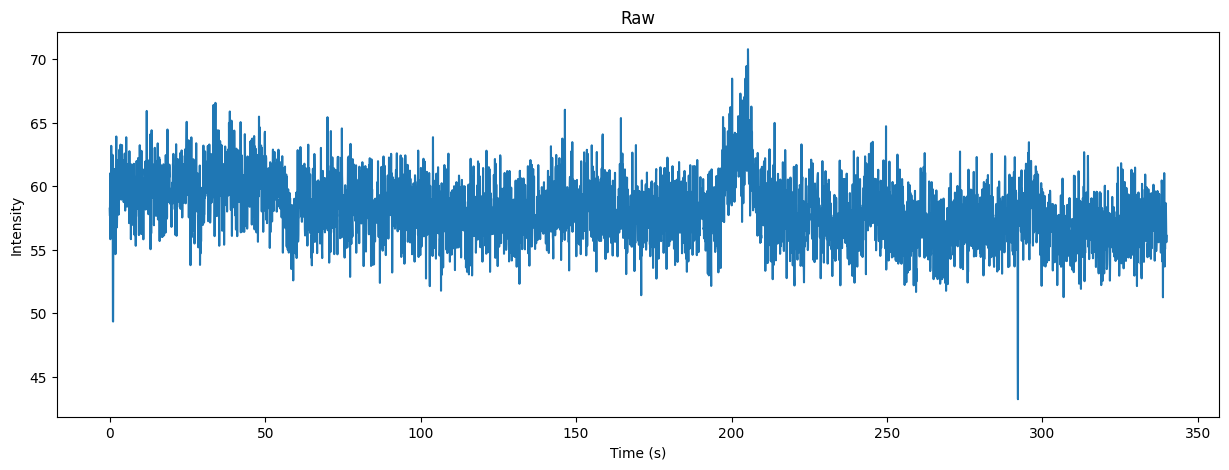

In [5]:
import numpy as np 
import matplotlib.pyplot as plt

#load data with numpy  
# use this function if you want to specify a range of columns to load: usecols(np.arange())  
signal = np.genfromtxt('/Users/Jeremy/Desktop/test.csv', encoding='utf-8-sig', delimiter = ',', usecols=np.arange(2,3), dtype='f8')
 
speed_of_imaging = float(input("Enter the speed of imaging (seconds/image): ")) #need to input because imaging speed can be different
dt = speed_of_imaging
print(f"Speed of imaging is {dt} seconds/image") 
n = len(signal) #counting the number of images there are in the time series 
print(f"There are {n} frames")

time_end = n*dt #how long it took to take the time series (in seconds)
print(f"This recording is {time_end} seconds long")
t = np.arange(0,time_end,dt) #creates a range that allows floats (for precision), where 0 is the start, time_end is the stop (which isn't included in the range), and dt is the step size 

plt.figure(figsize=(15, 5)) 
plt.plot(t,signal)
plt.title('Raw')
plt.xlabel("Time (s)")
plt.ylabel("Intensity")

/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


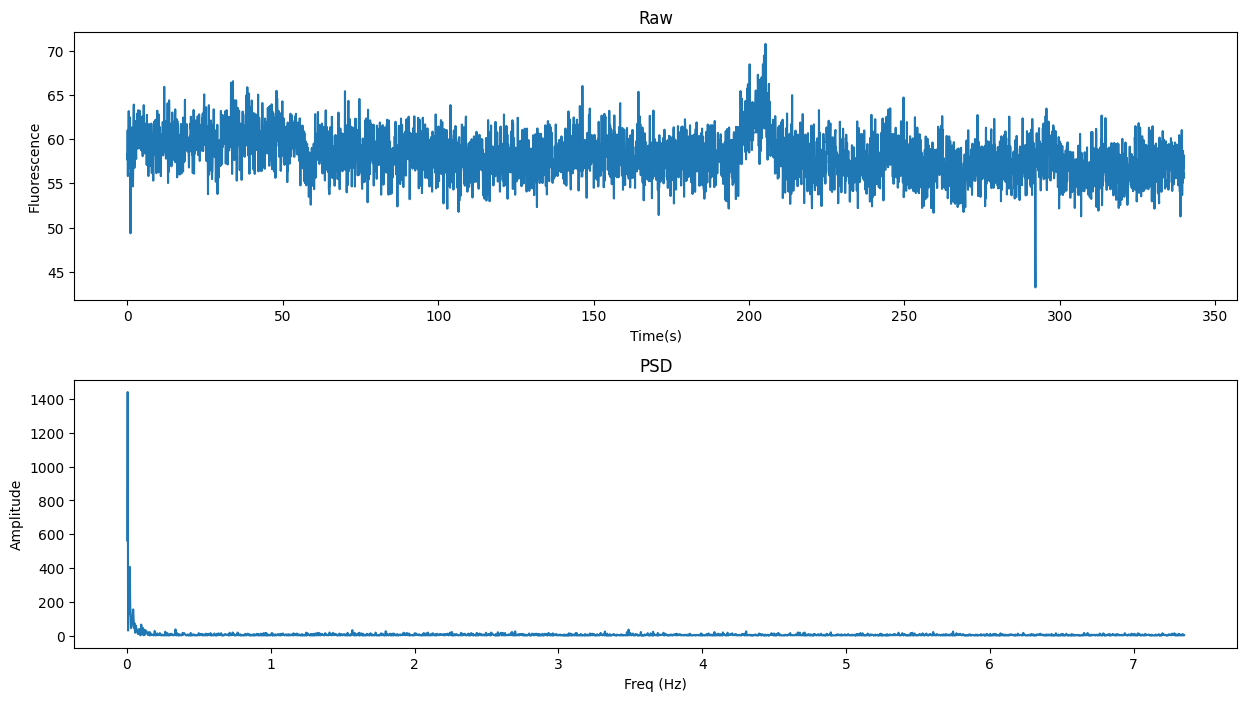

In [6]:
#FFT with numpy 

fhat = np.fft.fft(signal,n)     #compute the FFT
PSD = fhat * np.conj(fhat)/n    #Power spectrum density (gives you the magnitude of each fourier coefficient and we'll get a vector of powers at each frequency)
freq = (1/(dt*n))*np.arange(n)    #create an x-axis of frequencies 
L = np.arange(1,np.floor(n/2),dtype='int') #only plot first half (real signals are symmetric)

#plotting raw signal and power spectrum density acquired from FFT
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15,8))
x1=t
x2=freq[L]
y1=signal
y2=PSD[L]

ax1.plot(x1, y1)
ax1.set_title("Raw")
ax1.set_xlabel('Time(s)')
ax1.set_ylabel('Fluorescence')

ax2.plot(x2, y2)
ax2.set_title("PSD")
ax2.set_xlabel("Freq (Hz)")
ax2.set_ylabel("Amplitude")


plt.subplots_adjust(hspace=0.3)


In [7]:
#determine mean amplitude of PSD
power_spectrum_density = np.real(PSD) #takes only real values from the FFT
amplitude = np.sqrt(power_spectrum_density) #need to square root PSD since it is technically fhat^2

mean1s = np.mean(amplitude) #mean amplitude of power from PSD 
print(mean1s)


2.726235390932442


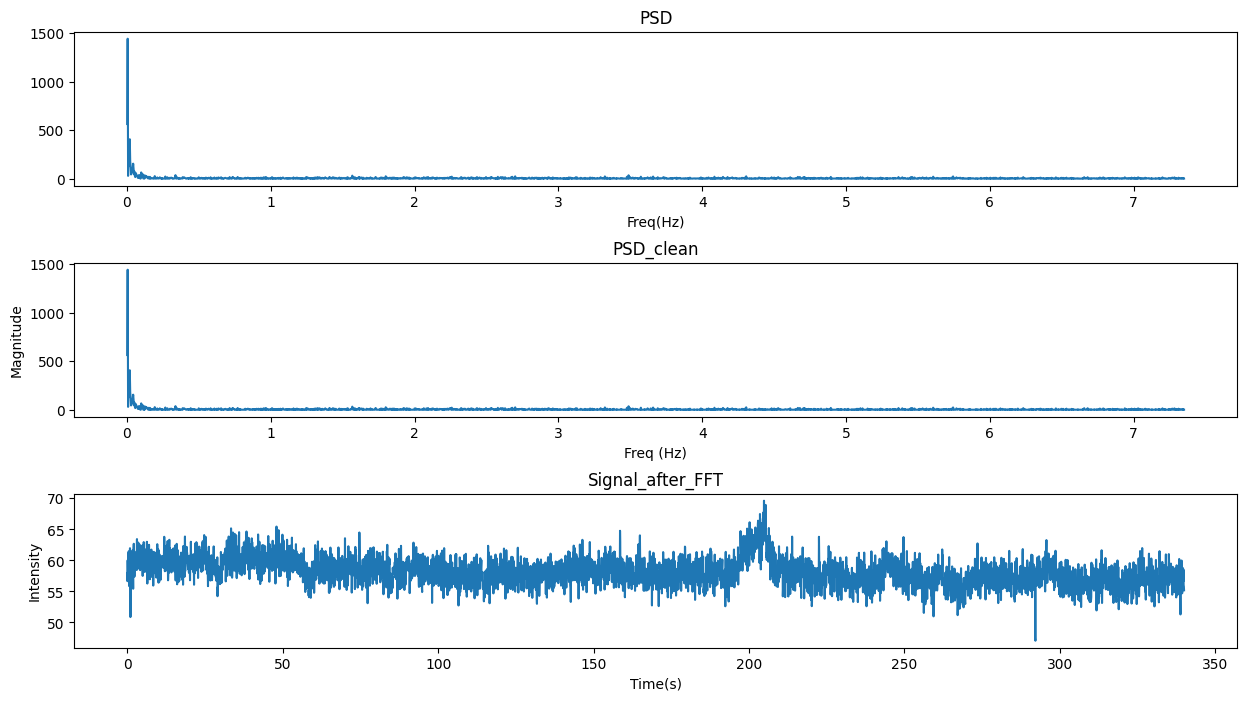

In [8]:
#Determine threshold value (can be a right above the noise floor or using a quartile approach), I chose 150% above mean 

#Set all FFT coefficients below the threshold to 0 and perform a reverse FFT to reconstruct signal without excluded frequencies

indices = PSD > mean1s*1.5 #threshold PSD to 150% times mean, this takes out most of the noise 
PSD_clean = PSD * indices
fhat_filt = indices * fhat 
ffilt = np.fft.ifft(fhat_filt)
complex_ifft_output = np.array(ffilt)
float_array = np.real(complex_ifft_output)

#np.savetxt('ffilt.csv', float_array, delimiter=',') #to save filtered signal 

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15,8))
x1=freq[L]
x2=t
y1=PSD[L]
y2=PSD_clean[L]
y3=ffilt        #can input float_array as well but output seems the same so I'm not sure what the difference is 

ax1.plot(x1, y1)
ax1.set_title("PSD")
ax1.set_xlabel('Freq(Hz)')

ax2.plot(x1, y2)
ax2.set_title("PSD_clean")
ax2.set_xlabel("Freq (Hz)")
ax2.set_ylabel("Magnitude")

ax3.plot(x2, y3)
ax3.set_title('Signal_after_FFT')
ax3.set_xlabel('Time(s)')
ax3.set_ylabel('Intensity')


plt.subplots_adjust(hspace=0.5)

The window size for rolling average is 59
4942 frames in the signal averaged by rolling window
Endpoint is 336.056s
4942 time points


Text(0, 0.5, 'Fluorescence')

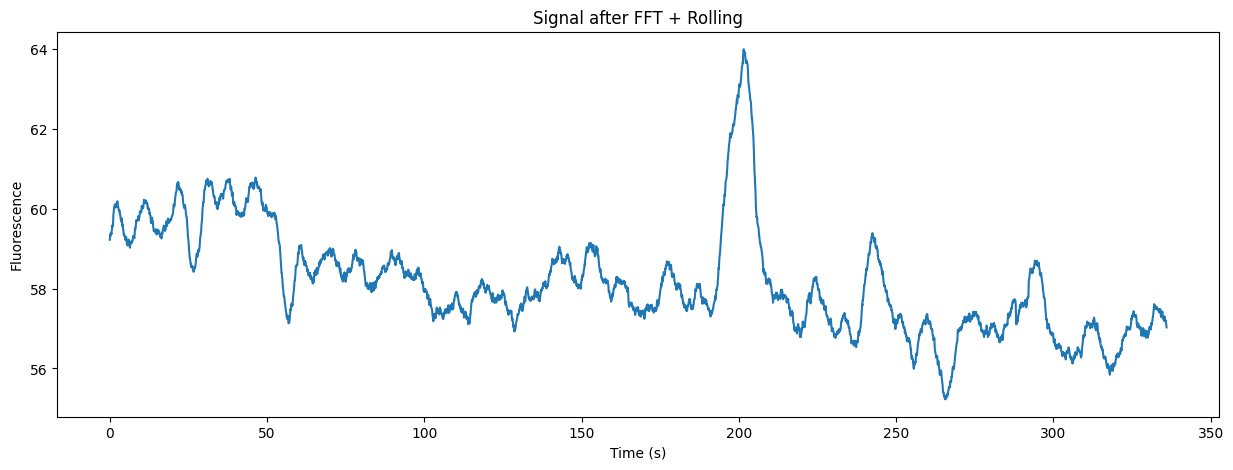

In [9]:
#Rolling average after FFT with Numpy

#make window size dependent on dt, aka images per second 
from sympy import symbols, Eq, solve 

y = symbols('y')
x = dt 
eq = Eq(4/x, y) #window size is based on time constant of 4 seconds
window_size = solve(eq, y)
window = window_size[0]
window_size = round(window) #need to round window size to nearest whole number 
window_size = int(window_size) #need to convert float to integer 
print(f"The window size for rolling average is {window_size}")
#rolling_mean = np.convolve(float_array, np.ones(window_size)/window_size, mode='valid')    #simpler rolling mean 

from numpy.lib.stride_tricks import sliding_window_view
windows = sliding_window_view(float_array, window_shape=window_size)    #can use np.convolve with mode='same' if you want the output to have the same length as the input (by calculating the edges with partial windows)
rolling_mean = windows.mean(axis=1)

print(f"{len(rolling_mean)} frames in the signal averaged by rolling window")

endpoint = time_end-(window_size-1.00000)*dt 
print(f"Endpoint is {endpoint}s") 

time = np.arange(0, endpoint, dt) #the last window-1 frames are cut off so we have to adjust the time accordingly
print(f"{len(time)} time points")

plt.figure(figsize=(15, 5)) 
plt.plot (time, rolling_mean)
plt.title('Signal after FFT + Rolling')
plt.xlabel("Time (s)")
plt.ylabel("Fluorescence")


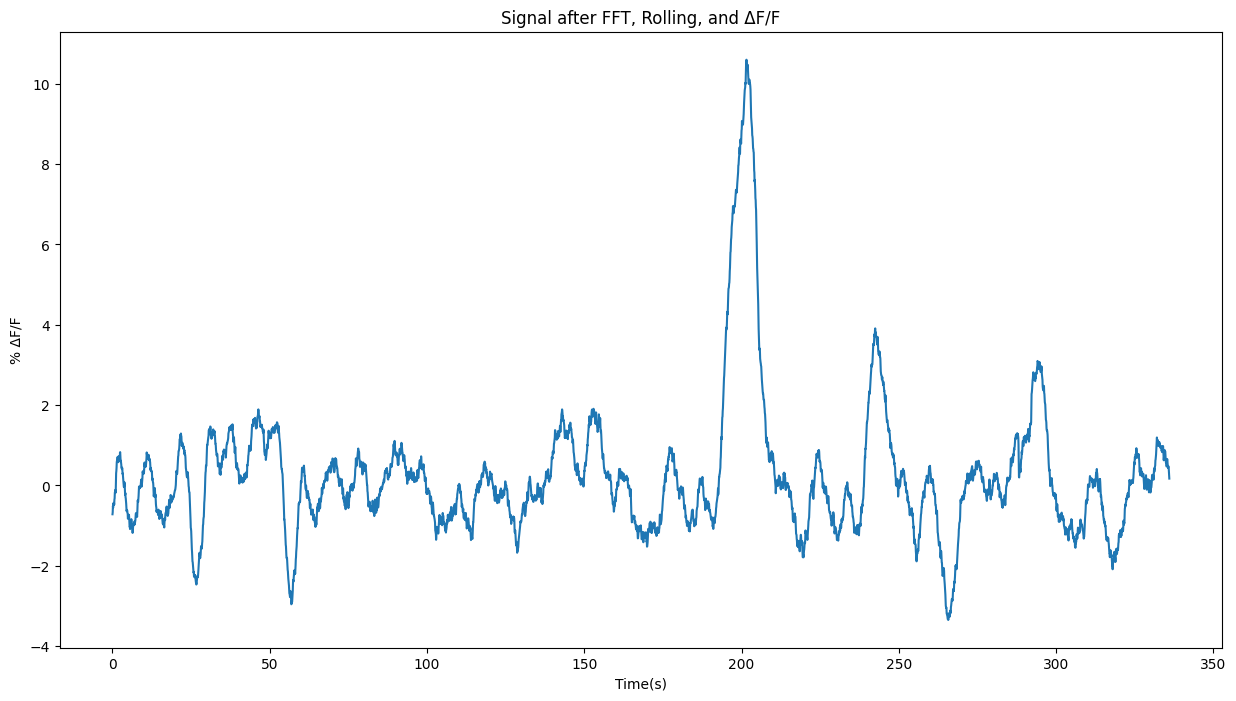

In [ ]:
# first compute F0 (baseline fluorescence) using moving percentile, better for when there's slow drifts in baseline fluroscence than using a static median
# then dF/F
from scipy.ndimage import generic_filter

#parameters
window_F0 =60*1/dt # Moving window size (60s window,  dt, in frames/s), seems long but there's not much activity 
window_F0 = round(window_F0)
percentile_value = 50 # 50th percentile

#apply moving percentage filter 
F0 = generic_filter(rolling_mean, function=lambda x: np.percentile(x, percentile_value), size=window_F0)

#noramlize data with F0 
dF_over_F = (rolling_mean - F0) / F0*100 # turned into percentage

fig, ax = plt.subplots(1,1, figsize=(15,8))                                    
x = time
y=dF_over_F
ax.plot(x,y)
ax.set_title('Signal after FFT, Rolling, and \u0394F/F')
ax.set_xlabel('Time(s)')
ax.set_ylabel('% \u0394F/F')
#plt.ylim(0,100)

dF = np.copy(dF_over_F) # need to create an independent copy of the variable to compare the arrays in the same cell for the next cell 


In [ ]:
'''
#Use Numpy to create percentage-based baseline; obsolete?

F0 = np.nanmedian(rolling_mean) #can use median because there's not a lot of ongoing activity (since there's not a lot of spikes that would pull the median above true baseline), otherwise would need to identify a specific percentile 
print(F0)

dF_over_F = (rolling_mean - F0) / F0*100 #turned into percentage 

plt.plot(time, dF_over_F)
plt.xlabel("Time (s)")
plt.ylabel("% DF/F")
plt.title("Signal after FFT, Rolling, and DF/F")
plt.ylim(0, 100)
'''

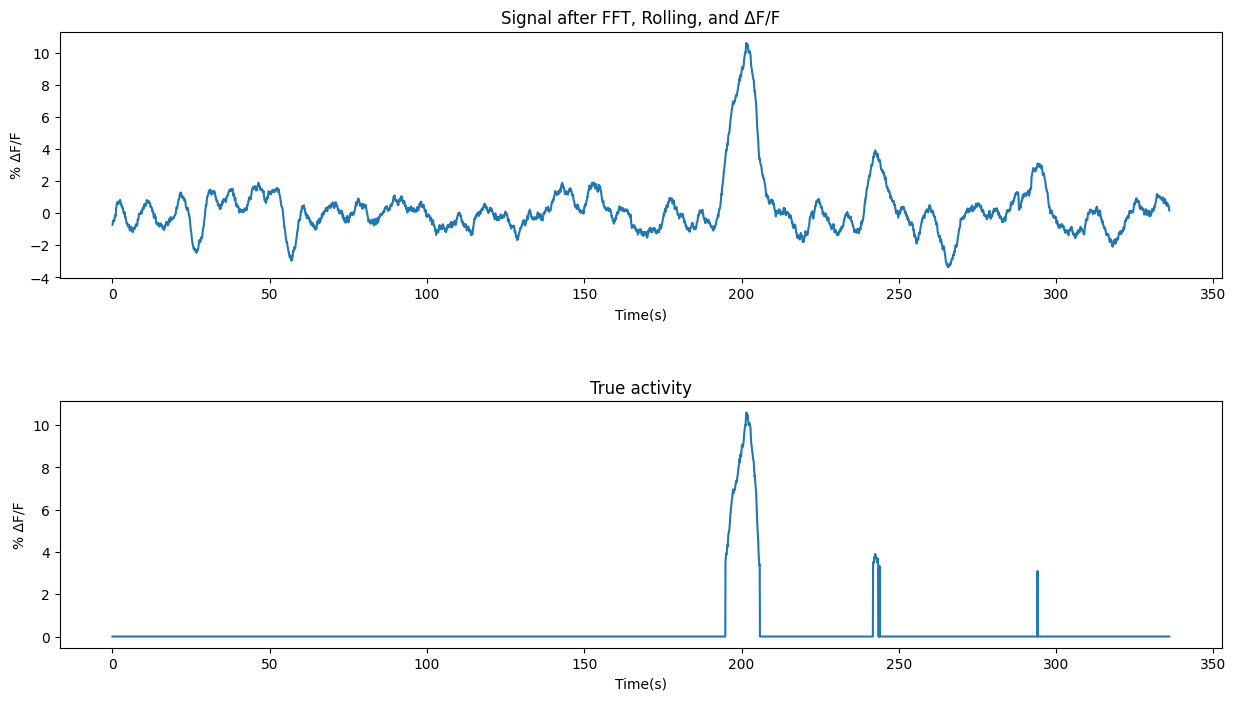

In [11]:
# event detection: applying a statistical significance threshold with z-scoring, better than setting a 10% dF/F threshold 


from scipy import stats 

thresholded = dF_over_F

for i in range(len(thresholded)):
    value = thresholded[i]

    z_score = stats.zscore(dF_over_F)

    if z_score[i] < 1.96: #threshold at 10% dF/F because noise seems to be just below it 
        thresholded[i] = value * 0  #values below threshold turns to 0, although this shortens signal so could find a better way to do this 


fig, axes = plt.subplots(2,1, figsize=(15,8))                                    
axes[0].plot(time,dF)
axes[0].set_title('Signal after FFT, Rolling, and \u0394F/F')
axes[0].set_xlabel('Time(s)')
axes[0].set_ylabel('% \u0394F/F')

axes[1].plot(time, thresholded)
axes[1].set_title("True activity")
axes[1].set_ylabel('% \u0394F/F')
axes[1].set_xlabel("Time(s)")
plt.subplots_adjust(hspace=0.5)



In [ ]:
#obsolete - event detection via setting the threshold at 10% dF/F  

'''
thresholded = dF_over_F

for i in range(len(thresholded)):
    value = thresholded[i]

    if value < 10: #threshold at 10% dF/F because noise seems to be just below it 
        thresholded[i] = value * 0  #values below threshold turns to 0, although this shortens signal so could find a better way to do this 

plt.plot(time, thresholded)
plt.title("True activity")
plt.ylabel(f"% dF/F")
plt.xlabel("Time(s)")
'''

AUC is 88.9883233007452 and the total activity is 0.2617303626492506 %dF/Fs


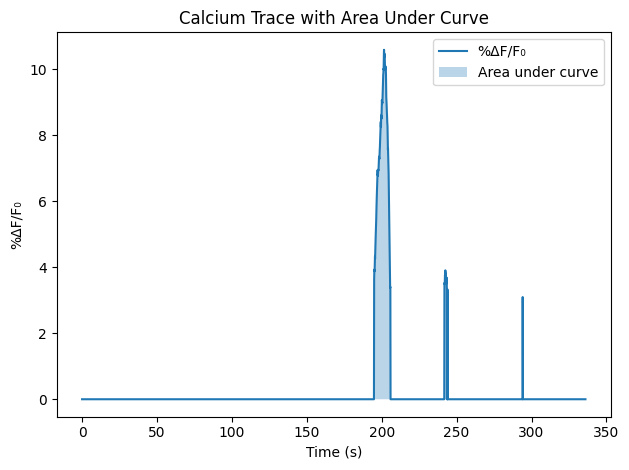

In [12]:
from scipy.integrate import simpson
from scipy.signal import peak_widths


t = np.arange(0, endpoint, dt)
auc = simpson(thresholded, t)
activity = auc/time_end
print(f"AUC is {auc} and the total activity is {activity} %dF/Fs")


plt.plot(t, dF_over_F, label='%ΔF/F₀')
plt.fill_between(t, dF_over_F, alpha=0.3, label='Area under curve') #alpha used for blending (values from 0-1) 
plt.xlabel('Time (s)')
plt.ylabel('%ΔF/F₀')
plt.title('Calcium Trace with Area Under Curve')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
'''
this part needs to be fixed 
also need to find a way to take out events shorter than 1.5s
'''

from scipy.signal import find_peaks, peak_widths

#fix this so that one signal doesn't have multiple if it's jagged
peaks, _ = find_peaks(dF_over_F) 
num_of_peaks = len(peaks)
print(f"This signal has {num_of_peaks} peaks at points {peaks}")

peak_w = peak_widths(dF_over_F, peaks, rel_height=1) #rel_height=1 means it takes the width at the base of the peak 
widths_seconds = peak_w[0] * dt
print(f"These events are {widths_seconds} seconds long")

#freq_events = num_of_peaks/time_end
freq_events = 1/time_end
print(f"The frequency of events in this ROI is {freq_events}/s") 

#average dF/F comes from auc/spike time
activity = auc/time_end
print(f"Total activity is {activity} %dF/F")

plt.figure
plt.plot(t, dF_over_F, label='%ΔF/F₀')
plt.plot(t[peaks], dF_over_F[peaks], "x", label='Peaks')
plt.hlines(peak_w[1], t[peak_w[2].astype(int)], t[peak_w[3].astype(int)],
           color="red", label='Widths')

plt.xlabel("Time (s)")
plt.ylabel("%ΔF/F₀")
plt.title("Peak Widths")
plt.legend()
plt.tight_layout()
plt.show()